In [1]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
import os
from pathlib import Path


def find_repo_root():
    current = Path.cwd().resolve()
    for candidate in (current, *current.parents):
        if (candidate / "scripts").exists() and (candidate / "notebooks").exists():
            return candidate
    return current


REPO_ROOT = find_repo_root()
SIM_ROOT = Path(os.environ.get("KN_SIM_ROOT", REPO_ROOT / "outputs" / "sim")).expanduser()
if "KN_SIM_ROOT" not in os.environ and "SNDATA_ROOT" in os.environ:
    SIM_ROOT = Path(os.environ["SNDATA_ROOT"]).expanduser() / "SIM"


def sim_dir(version):
    return SIM_ROOT / version


In [7]:
def plot_detection_scatter(
    wfst_head, wfst_phot, wfst_idx, wfst_snids,
    lsst_head, lsst_phot, lsst_idx, lsst_snids,
    snr_threshold=5, title='Kilonova Detection Count vs Time Range', debug=False
):
    """Plot 2D scatter of detection counts vs time range.
    
    Only plots events detected by both WFST and LSST.
    Shows two types of points:
    - WFST-only data (blue): using only WFST detections
    - WFST+LSST data (red): using combined detections from both surveys
    """
    wfst_n_det = []
    wfst_time_range = []
    combined_n_det = []
    combined_time_range = []

    # Only process events in both surveys
    overlap_snids = wfst_snids & lsst_snids
    
    for snid in overlap_snids:
        # Get WFST data
        wfst_start_index = wfst_head['PTROBS_MIN'][wfst_idx[snid][0]]
        wfst_end_index = wfst_head['PTROBS_MAX'][wfst_idx[snid][0]] + 1
        wfst_data = wfst_phot[wfst_start_index:wfst_end_index]

        wfst_flux = wfst_data['FLUXCAL']
        wfst_fluxerr = wfst_data['FLUXCALERR']
        wfst_snr = np.where(wfst_fluxerr > 0, wfst_flux / wfst_fluxerr, 0)
        wfst_mask_det = wfst_snr >= snr_threshold
        wfst_n = int(np.sum(wfst_mask_det))

        # Get LSST data
        lsst_start_index = lsst_head['PTROBS_MIN'][lsst_idx[snid][0]]
        lsst_end_index = lsst_head['PTROBS_MAX'][lsst_idx[snid][0]] + 1
        lsst_data = lsst_phot[lsst_start_index:lsst_end_index]

        lsst_flux = lsst_data['FLUXCAL']
        lsst_fluxerr = lsst_data['FLUXCALERR']
        lsst_snr = np.where(lsst_fluxerr > 0, lsst_flux / lsst_fluxerr, 0)
        lsst_mask_det = lsst_snr >= snr_threshold
        lsst_n = int(np.sum(lsst_mask_det))

        # Only include events where both surveys have at least one detection
        if wfst_n == 0 or lsst_n == 0:
            continue

        # Calculate WFST-only metrics
        wfst_mjd_det = wfst_data['MJD'][wfst_mask_det]
        wfst_trange = np.max(wfst_mjd_det) - np.min(wfst_mjd_det)
        wfst_n_det.append(wfst_n)
        wfst_time_range.append(wfst_trange)

        # Calculate combined WFST+LSST metrics
        lsst_mjd_det = lsst_data['MJD'][lsst_mask_det]
        all_mjd_det = np.concatenate([wfst_mjd_det, lsst_mjd_det])
        combined_n = wfst_n + lsst_n
        combined_trange = np.max(all_mjd_det) - np.min(all_mjd_det)
        combined_n_det.append(combined_n)
        combined_time_range.append(combined_trange)

        if debug and combined_n > 10:
            print(f"SNID {snid}: WFST={wfst_n}, LSST={lsst_n}, Combined={combined_n}")

    print(f"Events with both WFST and LSST detections: {len(wfst_n_det)}")
    print(f"Average WFST detections: {np.mean(wfst_n_det):.2f}")
    print(f"Average combined detections: {np.mean(combined_n_det):.2f}")

    plt.figure(figsize=(10, 8))
    plt.scatter(wfst_n_det, wfst_time_range,
               alpha=0.6, s=100, label='WFST only', color='blue', edgecolors='black', linewidths=0.5)
    plt.scatter(combined_n_det, combined_time_range,
               alpha=0.6, s=100, label='WFST + LSST', color='red', edgecolors='black', linewidths=0.5)
    plt.xlabel(f'Number of detections (SNR > {snr_threshold})', fontsize=14)
    plt.ylabel('Time range (days)', fontsize=14)
    plt.title(title, fontsize=16)
    plt.legend(fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    return {
        'wfst_n_det': wfst_n_det,
        'wfst_time_range': wfst_time_range,
        'combined_n_det': combined_n_det,
        'combined_time_range': combined_time_range,
    }


## Analyse LSST and WFST kilonova simulations for 170817A-like events

Simulate 100 seasons of kilonovae with LSST and WFST, using a power-law DNDZ and parameters similar to GW170817/AT2017gfo. Then analyse the results to determine detection rates and properties of detected events.

In [3]:
# Simulation version
wfst_version = 'WFST_KN_170817A'
lsst_version = 'LSST_KN_170817A'
# Load both simulations
wfst_path = sim_dir(wfst_version)
lsst_path = sim_dir(lsst_version)

wfst_head = fits.open(wfst_path / f'{wfst_version}_HEAD.FITS')[1].data
wfst_phot = fits.open(wfst_path / f'{wfst_version}_PHOT.FITS')[1].data
lsst_head = fits.open(lsst_path / f'{lsst_version}_HEAD.FITS')[1].data
lsst_phot = fits.open(lsst_path / f'{lsst_version}_PHOT.FITS')[1].data

# Find overlapping SNIDs
wfst_snids = set(s.strip() for s in wfst_head['SNID'])
lsst_snids = set(s.strip() for s in lsst_head['SNID'])
overlap_snids = sorted(wfst_snids & lsst_snids, key=int)

print(f"WFST events: {len(wfst_snids)}")
print(f"LSST events: {len(lsst_snids)}")
print(f"Overlapping events: {len(overlap_snids)}")
print(f"WFST-only: {len(wfst_snids - lsst_snids)}, LSST-only: {len(lsst_snids - wfst_snids)}")

# Build index lookup: SNID -> (row_index, ptrobs_min, ptrobs_max)
def build_index(head_data):
    idx = {}
    for i, snid in enumerate(head_data['SNID']):
        idx[snid.strip()] = (i, head_data['PTROBS_MIN'][i], head_data['PTROBS_MAX'][i])
    return idx

wfst_idx = build_index(wfst_head)
lsst_idx = build_index(lsst_head)


WFST events: 65
LSST events: 60
Overlapping events: 35
WFST-only: 30, LSST-only: 25


In [5]:
sum = 0
for snid in overlap_snids:
    wfst_start_index = wfst_head['PTROBS_MIN'][wfst_idx[snid][0]]
    wfst_end_index = wfst_head['PTROBS_MAX'][wfst_idx[snid][0]] + 1
    lsst_start_index = lsst_head['PTROBS_MIN'][lsst_idx[snid][0]]
    lsst_end_index = lsst_head['PTROBS_MAX'][lsst_idx[snid][0]] + 1
    wfst_data = wfst_phot[wfst_start_index:wfst_end_index]
    lsst_data = lsst_phot[lsst_start_index:lsst_end_index]

    wfst_flux = wfst_data['FLUXCAL']
    wfst_fluxerr = wfst_data['FLUXCALERR']
    wfst_snr = np.where(wfst_fluxerr > 0, wfst_flux / wfst_fluxerr, 0)

    wfst_mask_det = wfst_snr >= 5
    if np.sum(wfst_mask_det) != 1:
        continue
    lsst_flux = lsst_data['FLUXCAL']
    lsst_fluxerr = lsst_data['FLUXCALERR']
    lsst_snr = np.where(lsst_fluxerr > 0, lsst_flux / lsst_fluxerr, 0)
    lsst_mask_det = lsst_snr >= 5
    if np.sum(lsst_mask_det) >= 1:
        sum += 1
        
print(f"Number of overlapping events with >1 LSST detection and exactly 1 WFST detection: {sum}")

Number of overlapping events with >1 LSST detection and exactly 1 WFST detection: 4


Events with both WFST and LSST detections: 33
Average WFST detections: 3.06
Average combined detections: 6.06


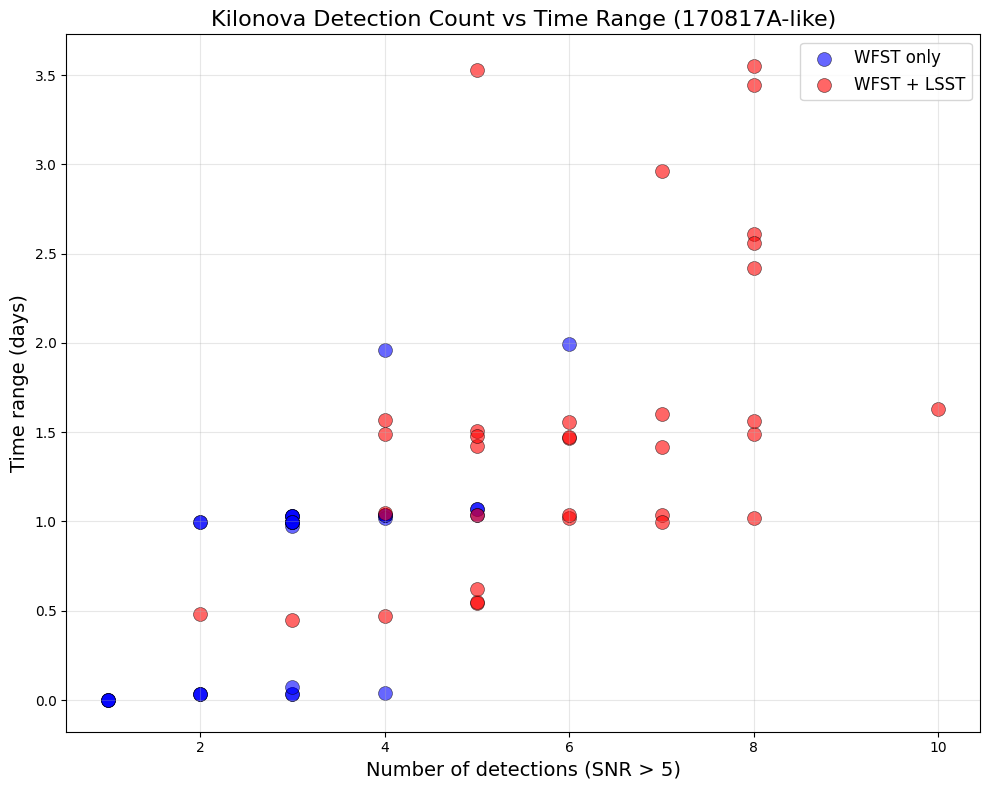

In [8]:
# Plot the 2D scatter plot of N_det and time range
results = plot_detection_scatter(
    wfst_head, wfst_phot, wfst_idx, wfst_snids,
    lsst_head, lsst_phot, lsst_idx, lsst_snids,
    snr_threshold=5,
    title='Kilonova Detection Count vs Time Range (170817A-like)'
)


## Analyse simulation for astrophysical population

Number of simulated BNS events: 387

In [2]:
# Simulation version
wfst_version = 'WFST_KN_ASTRO_COMBINED'
lsst_version = 'LSST_KN_ASTRO_COMBINED'
# Load both simulations
wfst_path = sim_dir(wfst_version)
lsst_path = sim_dir(lsst_version)

wfst_head = fits.open(wfst_path / f'{wfst_version}_HEAD.FITS')[1].data
wfst_phot = fits.open(wfst_path / f'{wfst_version}_PHOT.FITS')[1].data
lsst_head = fits.open(lsst_path / f'{lsst_version}_HEAD.FITS')[1].data
lsst_phot = fits.open(lsst_path / f'{lsst_version}_PHOT.FITS')[1].data

# Find overlapping SNIDs
wfst_snids = set(s.strip() for s in wfst_head['SNID'])
lsst_snids = set(s.strip() for s in lsst_head['SNID'])
overlap_snids = sorted(wfst_snids & lsst_snids, key=int)

print(f"WFST events: {len(wfst_snids)}")
print(f"LSST events: {len(lsst_snids)}")
print(f"Overlapping events: {len(overlap_snids)}")
print(f"WFST-only: {len(wfst_snids - lsst_snids)}, LSST-only: {len(lsst_snids - wfst_snids)}")

# Build index lookup: SNID -> (row_index, ptrobs_min, ptrobs_max)
def build_index(head_data):
    idx = {}
    for i, snid in enumerate(head_data['SNID']):
        idx[snid.strip()] = (i, head_data['PTROBS_MIN'][i], head_data['PTROBS_MAX'][i])
    return idx

wfst_idx = build_index(wfst_head)
lsst_idx = build_index(lsst_head)


WFST events: 11
LSST events: 8
Overlapping events: 6
WFST-only: 5, LSST-only: 2


Events with both WFST and LSST detections: 6
Average WFST detections: 3.00
Average combined detections: 4.67


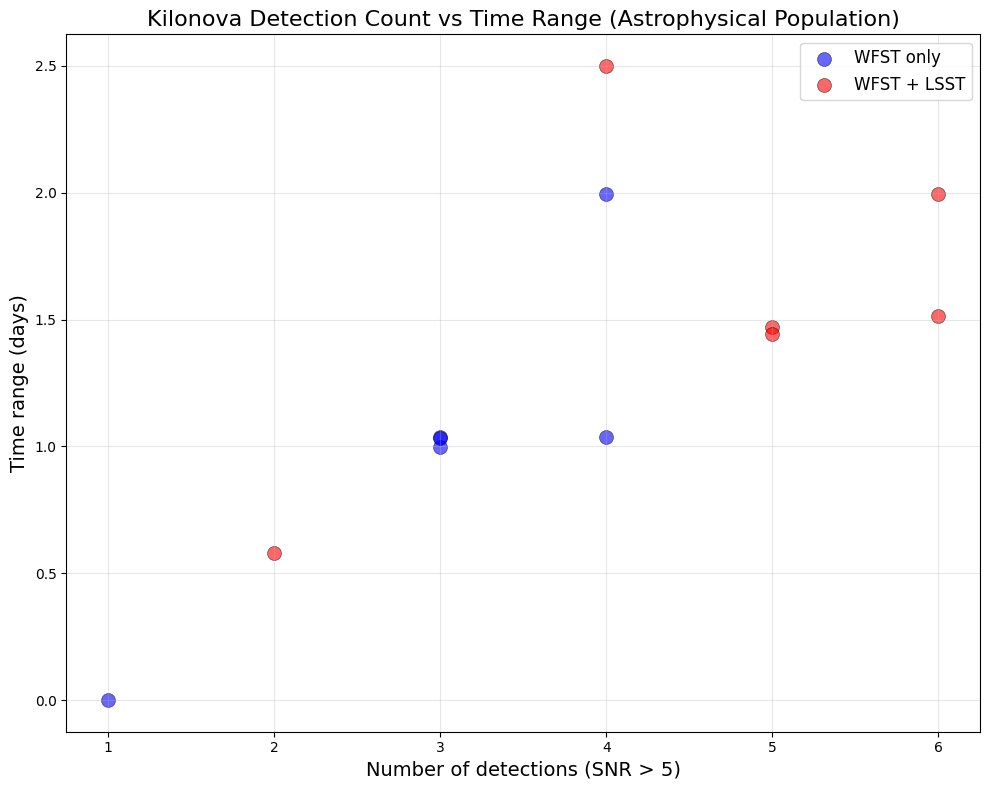

In [10]:
# Plot the 2D scatter plot of N_det and time range
results = plot_detection_scatter(
    wfst_head, wfst_phot, wfst_idx, wfst_snids,
    lsst_head, lsst_phot, lsst_idx, lsst_snids,
    snr_threshold=5,
    title='Kilonova Detection Count vs Time Range (Astrophysical Population)'
)
